<a href="https://colab.research.google.com/github/Shivam-vachhani/PyTorch-Projects/blob/main/ANN_Model_with_Optuna_Hyper_Parameterized_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset ,DataLoader


In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv('fashion-mnist_train.csv')

In [4]:
#check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cupu')
print(f"device : {device}")

device : cuda


In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


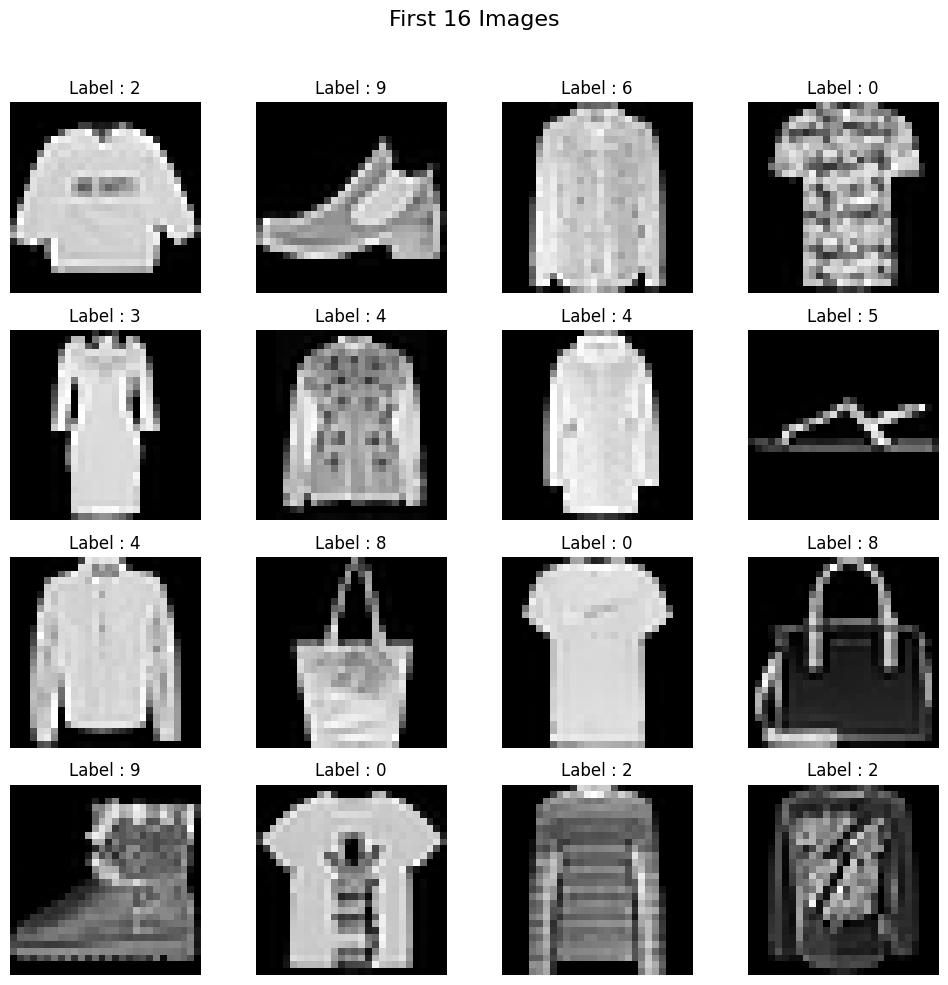

In [6]:
# show imges using matplot lin from dataset
fig ,axes  = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images",fontsize=16)

#loop through axes and datarow at same time
for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28) #getting data into reshape matrix 28*28
  ax.imshow(img, cmap='gray',interpolation='nearest') #show image
  ax.axis('off') # Remove axis to look clean
  ax.set_title(f"Label : {df.iloc[i,0]}")# set label

plt.tight_layout(rect=[0,0,1,0.96]) # make layout
plt.show()

In [7]:
# split data
X = df.iloc[:,1:].values
y = df.iloc[:,0].values


In [8]:
train_X,test_X,train_y,test_y = train_test_split(X,y,test_size=0.2,random_state=42)


In [9]:
#Scaling rgb values between 0 to 1
train_X = train_X/255.0
test_X = test_X/255.0

In [10]:
# Create custom dataset Class
class CustomDataset(Dataset):

  def __init__(self,features,labels):
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]



In [11]:
# Create train and test dataset object
train_dataset = CustomDataset(train_X,train_y)
test_dataset = CustomDataset(test_X,test_y)


In [14]:
# train_dataset[0]

In [21]:
class MyNN(nn.Module):

  def __init__(self,input_dim,output_dim,num_hidden_layers,neurons_per_layer,drop_rate):
    super().__init__()

    layers = []

    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim,neurons_per_layer))
      layers.append(nn.BatchNorm1d(neurons_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(drop_rate))
      input_dim = neurons_per_layer

    layers.append(nn.Linear(input_dim,output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,X):
    return self.model(X)

In [24]:
from re import A
# objective function

def objective(trial):

  #hyperperameter values from the search space
  num_hidden_layers = trial.suggest_int('num_hidden_layers',1,10)
  neurons_per_layer = trial.suggest_int('neurons_per_layer',8,128,step=8)
  drop_rate = trial.suggest_float('drop_rate',0.1,0.5,step=0.1)
  learning_rate = trial.suggest_float('learning_rate',1e-5,1e-1,log=True)
  epochs = trial.suggest_int('epochs',10,100,step=10)
  batch_size = trial.suggest_categorical('batch_size',[16,32,64,128,256,512])
  optimizer_name = trial.suggest_categorical('optimizer_name',['Adam','SDG','RMSprop'])
  weight_decay = trial.suggest_float('weight_decay',1e-5,1e-3,log=True)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

  # init model
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim,output_dim,num_hidden_layers,neurons_per_layer,drop_rate)
  model.to(device)


  #Loss function
  criterion = nn.CrossEntropyLoss()

  if optimizer_name == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name == 'SGD':
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  else:
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)


  # Train our model with batches and ephocs
  for epoch in range(epochs):
    total_epoch_loss = 0
    for batch_features, batch_label in train_loader:

      #movedata to gpu
      batch_features ,batch_label = batch_features.to(device),batch_label.to(device)

      #forward pass
      outputs = model(batch_features)

      #loss calulate
      loss = criterion(outputs,batch_label)

      #backward pass
      optimizer.zero_grad()
      loss.backward()

      #update grad
      optimizer.step()

      total_epoch_loss += loss.item()

  # set model to eval mode
  model.eval()

  # defining accuracy of our model on test dataset
  total = 0
  correct = 0

  with torch.no_grad():
    for batch_features, batch_label in test_loader:
      #movedata to gpu
      batch_features ,batch_label = batch_features.to(device),batch_label.to(device)
      outputs = model(batch_features)
      _, predicted = torch.max(outputs,1)
      total += batch_label.shape[0]
      correct += (predicted == batch_label).sum().item()

  accuracy = correct/total

  return accuracy

In [25]:
!pip install optuna

In [ ]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective , n_trials=10)

[I 2026-04-15 13:29:48,540] A new study created in memory with name: no-name-55f2540a-97c8-47ab-bddd-da47e724b8ca
[I 2026-04-15 13:30:45,652] Trial 0 finished with value: 0.8729166666666667 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 64, 'drop_rate': 0.30000000000000004, 'learning_rate': 0.00027858942144170986, 'epochs': 10, 'batch_size': 16, 'optimizer_name': 'Adam', 'weight_decay': 1.9200378715966847e-05}. Best is trial 0 with value: 0.8729166666666667.
[I 2026-04-15 13:33:10,451] Trial 1 finished with value: 0.8724166666666666 and parameters: {'num_hidden_layers': 1, 'neurons_per_layer': 80, 'drop_rate': 0.5, 'learning_rate': 1.8529390175036396e-05, 'epochs': 90, 'batch_size': 64, 'optimizer_name': 'SDG', 'weight_decay': 4.902548609929636e-05}. Best is trial 0 with value: 0.8729166666666667.
[I 2026-04-15 13:33:45,013] Trial 2 finished with value: 0.33958333333333335 and parameters: {'num_hidden_layers': 9, 'neurons_per_layer': 24, 'drop_rate': 0.5, 'learning_rate'